In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv']

In [4]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab/WineQT.csv")

print("Dataset loaded successfully! 🎉")

df.head()

Dataset loaded successfully! 🎉


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [5]:
import os

print(os.listdir())

['.config', 'drive', 'sample_data']


In [6]:
from google.colab import files

uploaded = files.upload()

Saving WineQT.csv to WineQT.csv


LINEAR REGRESSION AND REGULARISATION PROJECT

Dataset Loaded Successfully!

Dataset Shape:
(1143, 13)

First 5 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0

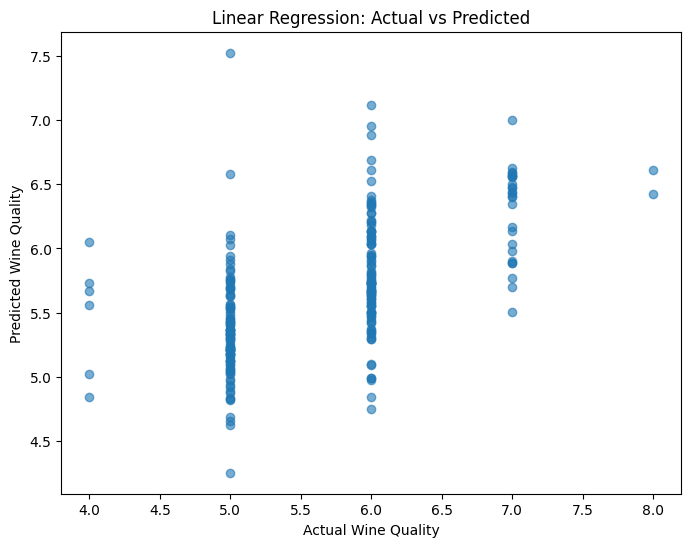

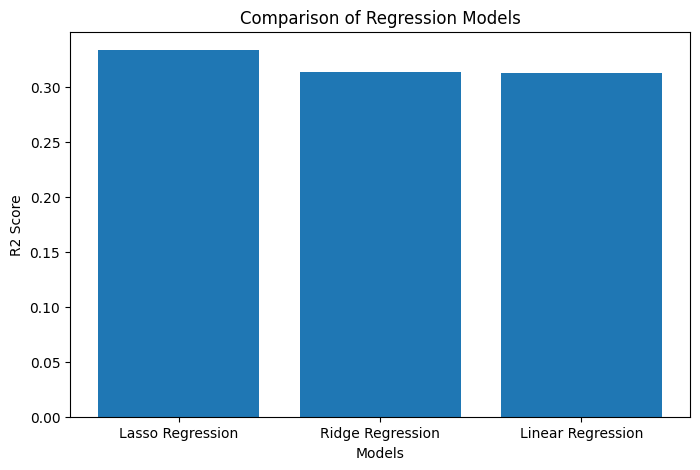


Results saved successfully!
File Name: linear_regression_regularisation_results.csv

FINAL CONCLUSION

The Wine Quality dataset was used to compare
Linear Regression, Ridge Regression, and Lasso Regression.

The models were evaluated using:

1. MAE
2. MSE
3. RMSE
4. R² Score

The best performing model based on R² Score is:

Lasso Regression

with an R² Score of:

0.3333



In [7]:
# ============================================================
# LINEAR REGRESSION AND REGULARISATION PROJECT
# Dataset: WineQT.csv
# Models:
# 1. Linear Regression
# 2. Ridge Regression (L2 Regularisation)
# 3. Lasso Regression (L1 Regularisation)
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ------------------------------------------------------------
# 2. CONFIGURATION
# ------------------------------------------------------------

RANDOM_STATE = 42

DATA_PATH = "WineQT.csv"

# Target variable for Wine Quality dataset
TARGET_COL = "quality"


# ------------------------------------------------------------
# 3. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("LINEAR REGRESSION AND REGULARISATION PROJECT")
print("=" * 60)

print("\nDataset Loaded Successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ------------------------------------------------------------
# 4. DATASET INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


# ------------------------------------------------------------
# 5. CHECK DUPLICATES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

duplicates = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)


# ------------------------------------------------------------
# 6. HANDLE MISSING VALUES
# ------------------------------------------------------------

# Separate target and features

X = df.drop(columns=[TARGET_COL])

y = df[TARGET_COL]


# Find numerical columns

num_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns


# Median imputation

imputer = SimpleImputer(
    strategy="median"
)

X[num_cols] = imputer.fit_transform(
    X[num_cols]
)


print("\nMissing values handled successfully!")


# ------------------------------------------------------------
# 7. FEATURE SCALING
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# Convert back to DataFrame

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)


print("\nFeature Scaling Completed!")


# ------------------------------------------------------------
# 8. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,

    y,

    test_size=0.20,

    random_state=RANDOM_STATE

)


print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)


# ------------------------------------------------------------
# 9. CREATE MODELS
# ------------------------------------------------------------

linear_model = LinearRegression()

ridge_model = Ridge(
    alpha=1.0
)

lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)


# ------------------------------------------------------------
# 10. TRAIN MODELS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING MODELS")
print("=" * 60)


# Linear Regression

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression Trained Successfully!")


# Ridge Regression

ridge_model.fit(
    X_train,
    y_train
)

print("Ridge Regression Trained Successfully!")


# Lasso Regression

lasso_model.fit(
    X_train,
    y_train
)

print("Lasso Regression Trained Successfully!")


# ------------------------------------------------------------
# 11. MAKE PREDICTIONS
# ------------------------------------------------------------

linear_pred = linear_model.predict(
    X_test
)

ridge_pred = ridge_model.predict(
    X_test
)

lasso_pred = lasso_model.predict(
    X_test
)


# ------------------------------------------------------------
# 12. MODEL EVALUATION FUNCTION
# ------------------------------------------------------------

def evaluate_model(
    model_name,
    y_actual,
    y_predicted
):

    mae = mean_absolute_error(
        y_actual,
        y_predicted
    )

    mse = mean_squared_error(
        y_actual,
        y_predicted
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_actual,
        y_predicted
    )

    return {

        "Model": model_name,

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2 Score": r2

    }


# ------------------------------------------------------------
# 13. EVALUATE ALL MODELS
# ------------------------------------------------------------

results = []


results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)


results.append(
    evaluate_model(
        "Ridge Regression",
        y_test,
        ridge_pred
    )
)


results.append(
    evaluate_model(
        "Lasso Regression",
        y_test,
        lasso_pred
    )
)


# ------------------------------------------------------------
# 14. CREATE RESULTS DATAFRAME
# ------------------------------------------------------------

results_df = pd.DataFrame(
    results
)


# Sort by R² Score

results_df = results_df.sort_values(

    by="R2 Score",

    ascending=False

).reset_index(
    drop=True
)


print("\n" + "=" * 60)
print("MODEL COMPARISON RESULTS")
print("=" * 60)

print(
    results_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 15. BEST MODEL
# ------------------------------------------------------------

best_model = results_df.iloc[0]

print("\n" + "=" * 60)
print("BEST MODEL")
print("=" * 60)

print(
    "Best Model:",
    best_model["Model"]
)

print(
    "Best R2 Score:",
    round(
        best_model["R2 Score"],
        4
    )
)


# ------------------------------------------------------------
# 16. ACTUAL VS PREDICTED GRAPH
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)


plt.scatter(

    y_test,

    linear_pred,

    alpha=0.6

)


plt.xlabel(
    "Actual Wine Quality"
)

plt.ylabel(
    "Predicted Wine Quality"
)

plt.title(
    "Linear Regression: Actual vs Predicted"
)


plt.show()


# ------------------------------------------------------------
# 17. COMPARE R² SCORES
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)


plt.bar(

    results_df["Model"],

    results_df["R2 Score"]

)


plt.xlabel(
    "Models"
)

plt.ylabel(
    "R2 Score"
)

plt.title(
    "Comparison of Regression Models"
)


plt.show()


# ------------------------------------------------------------
# 18. SAVE RESULTS
# ------------------------------------------------------------

results_df.to_csv(

    "linear_regression_regularisation_results.csv",

    index=False

)


print("\nResults saved successfully!")

print(
    "File Name: linear_regression_regularisation_results.csv"
)


# ------------------------------------------------------------
# 19. FINAL CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)

print(
    f"""
The Wine Quality dataset was used to compare
Linear Regression, Ridge Regression, and Lasso Regression.

The models were evaluated using:

1. MAE
2. MSE
3. RMSE
4. R² Score

The best performing model based on R² Score is:

{best_model["Model"]}

with an R² Score of:

{best_model["R2 Score"]:.4f}
"""
)

print("=" * 60)